# Objective

Implement an object detection pipeline using YOLO26 to detect objects, extract bounding boxes and class labels, apply a confidence threshold, manually draw detections, and generate a descriptive summary.

## Tools

Google Colab, Python, YOLO26, NumPy, PIL, OpenCV, and Matplotlib.


## 1. Load the Image

Load a basketball player image and convert it to RGB format.


Image shape: (448, 446, 3)


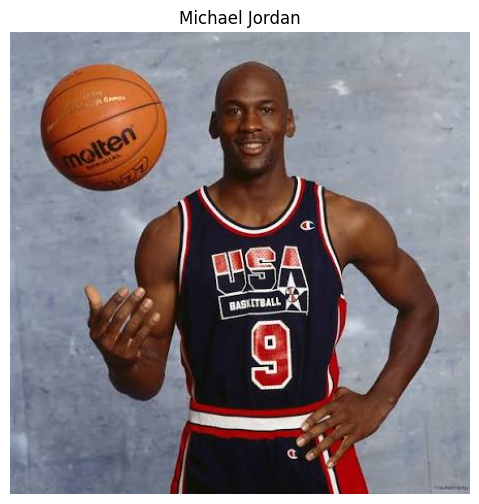

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

image_url = "https://raw.githubusercontent.com/MashaelAlshehir/Computer-Vision-Final-Project/main/images/Michael-Jordan.jpeg"

response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

image_np = np.array(image)

print("Image shape:", image_np.shape)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title("Michael Jordan")
plt.axis("off")
plt.show()


## 2. YOLO26 Object Detection

Run YOLO26 inference to detect objects in the image.


In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import YOLO

# Load YOLO26 model
model = YOLO("yolo26n.pt")

# Run inference on the image
results = model(image)

# Display detection results
print(results)


0: 640x640 1 person, 1 sports ball, 1 baseball glove, 289.0ms
Speed: 8.0ms preprocess, 289.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana

## 3. Bounding Boxes and Labels

Extract the detection coordinates and class labels, apply a confidence threshold, and manually draw the bounding boxes.


In [ ]:
# Get the detection results
result = results[0]

# Check detected objects
print(result.boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 0., 32., 35.])
conf: tensor([0.9563, 0.7973, 0.2832])
data: tensor([[6.4188e+01, 2.7638e+01, 4.1890e+02, 4.4800e+02, 9.5631e-01, 0.0000e+00],
        [2.8092e+01, 2.9995e+01, 1.5385e+02, 1.5611e+02, 7.9726e-01, 3.2000e+01],
        [7.3264e+01, 2.4485e+02, 1.4113e+02, 3.1912e+02, 2.8319e-01, 3.5000e+01]])
id: None
is_track: False
orig_shape: (448, 446)
shape: torch.Size([3, 6])
xywh: tensor([[241.5437, 237.8192, 354.7112, 420.3616],
        [ 90.9702,  93.0517, 125.7566, 126.1139],
        [107.1949, 281.9886,  67.8615,  74.2718]])
xywhn: tensor([[0.5416, 0.5308, 0.7953, 0.9383],
        [0.2040, 0.2077, 0.2820, 0.2815],
        [0.2403, 0.6294, 0.1522, 0.1658]])
xyxy: tensor([[ 64.1881,  27.6384, 418.8993, 448.0000],
        [ 28.0919,  29.9947, 153.8485, 156.1086],
        [ 73.2642, 244.8528, 141.1257, 319.1245]])
xyxyn: tensor([[0.1439, 0.0617, 0.9392, 1.0000],
        [0.0630, 0.0670, 0.3450, 0.3485],
        

In [ ]:
# Extract detection information
for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    coordinates = box.xyxy[0].tolist()

    class_name = result.names[class_id]

    print(
        f"Class: {class_name} | "
        f"Confidence: {confidence:.2f} | "
        f"Box: {coordinates}"
    )

Class: person | Confidence: 0.96 | Box: [64.18812561035156, 27.638389587402344, 418.8993225097656, 448.0]
Class: sports ball | Confidence: 0.80 | Box: [28.091899871826172, 29.994714736938477, 153.84848022460938, 156.108642578125]
Class: baseball glove | Confidence: 0.28 | Box: [73.26416778564453, 244.85276794433594, 141.1256561279297, 319.1245422363281]


In [ ]:
# Confidence threshold
confidence_threshold = 0.5

# Store valid detections
detections = []

for box in result.boxes:
    confidence = float(box.conf[0])

    if confidence >= confidence_threshold:
        class_id = int(box.cls[0])
        class_name = result.names[class_id]

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        detections.append({
            "class": class_name,
            "confidence": confidence,
            "box": (x1, y1, x2, y2)
        })

# Display filtered detections
for detection in detections:
    print(
        f"Class: {detection['class']} | "
        f"Confidence: {detection['confidence']:.2f} | "
        f"Box: {detection['box']}"
    )

Class: person | Confidence: 0.96 | Box: (64, 27, 418, 448)
Class: sports ball | Confidence: 0.80 | Box: (28, 29, 153, 156)


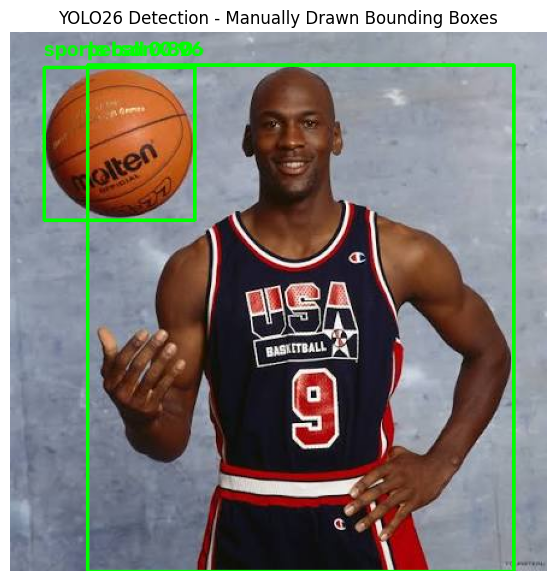

In [ ]:
import cv2

# Convert RGB image to BGR for OpenCV
image_with_boxes = cv2.cvtColor(image_np.copy(), cv2.COLOR_RGB2BGR)

for detection in detections:
    x1, y1, x2, y2 = detection["box"]
    class_name = detection["class"]
    confidence = detection["confidence"]

    # Draw bounding box
    cv2.rectangle(
        image_with_boxes,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Write class name above the box
    label = f"{class_name} {confidence:.2f}"

    cv2.putText(
        image_with_boxes,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# Convert back to RGB for displaying with Matplotlib
image_with_boxes = cv2.cvtColor(
    image_with_boxes,
    cv2.COLOR_BGR2RGB
)

# Display result
plt.figure(figsize=(10, 7))
plt.imshow(image_with_boxes)
plt.title("YOLO26 Detection - Manually Drawn Bounding Boxes")
plt.axis("off")
plt.show()

## 4. Descriptive Summary

Generate a natural language description of the detected objects in the image.


In [ ]:
# Generate a descriptive summary
if detections:
    objects = [d["class"] for d in detections]

    # Count detected objects
    object_counts = {}

    for obj in objects:
        object_counts[obj] = object_counts.get(obj, 0) + 1

    # Create object description
    descriptions = []

    for obj, count in object_counts.items():
        if count == 1:
            descriptions.append(f"1 {obj}")
        else:
            descriptions.append(f"{count} {obj}s")

    summary = "The image contains " + ", ".join(descriptions) + "."

else:
    summary = "No objects were detected above the confidence threshold."

print(summary)


The image contains 1 person, 1 sports ball.


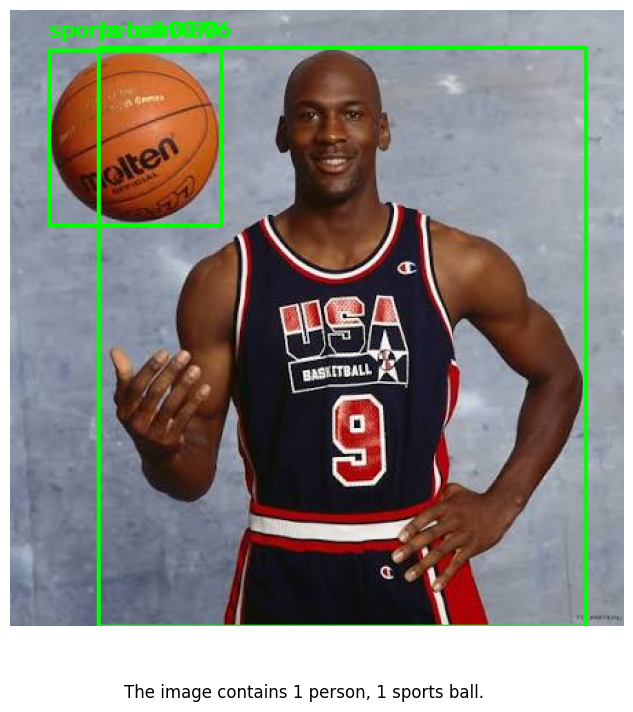

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(image_with_boxes)
plt.axis("off")

plt.figtext(
    0.5,
    0.02,
    summary,
    ha="center",
    fontsize=12,
    wrap=True
)

plt.show()

## Conclusion

The image was processed using YOLO26 to detect objects, visualize the results, and generate a descriptive summary.